### 9.2.2 从零开始实现

In [1]:
import torch
from torch import nn
from d2l import torch as d2l

In [2]:
batch_size, num_steps = 32, 35
train_iter, vocab = d2l.load_data_time_machine(batch_size, num_steps)

初始化模型参数

In [10]:
def get_lstm_params(batch_size, num_hiddens, device):
    num_inputs = num_outputs = vocab_size

    def normal(shape):
        return torch.randn(size=shape, device=device) * 0.01

    def three():
        return (
            normal((num_inputs, num_hiddens)),
            normal((num_hiddens, num_hiddens)),
            torch.zeros(num_hiddens, device=device)
        )

    W_xi, W_hi, b_i = three()  # 输入门参数
    W_xf, W_hf, b_f = three()  # 遗忘门参数
    W_xo, W_ho, b_o = three()  # 输出门参数
    W_xc, W_hc, b_c = three()  # 候选记忆元参数

    # 输出层参数
    W_hq = normal((num_hiddens, num_outputs))
    b_q = torch.zeros(num_outputs, device=device)

    # 附加梯度
    params = [W_xi, W_hi, b_i, W_xf, W_hf, b_f, W_xo, W_ho, b_o, W_xc, W_hc, b_c, W_hq, b_q]
    for param in params:
        param.requires_grad_(True)

    return params

定义模型

In [4]:
def init_lstm_state(batch_size, num_hiddens, device):
    return (torch.zeros((batch_size, num_hiddens), device=device),
            torch.zeros((batch_size, num_hiddens), device=device))

In [5]:
def lstm(inputs, state, params):
    W_xi, W_hi, b_i, W_xf, W_hf, b_f, W_xo, W_ho, b_o, W_xc, W_hc, b_c, W_hq, b_q = params
    (H, C) = state
    outputs = []

    for X in inputs:
        I = torch.sigmoid((X @ W_xi) + (H @ W_hi) + b_i)
        F = torch.sigmoid((X @ W_xf) + (H @ W_hf) + b_f)
        O = torch.sigmoid((X @ W_xo) + (H @ W_ho) + b_o)
        C_tilda = torch.tanh((X @ W_xc) + (H @ W_hc) + b_c)
        C = F * C + I * C_tilda
        H = O * torch.tanh(C)
        Y = (H @ W_hq) + b_q
        outputs.append(Y)

    return torch.cat(outputs, dim=0), (H, C)

训练和预测

/Users/kukudehui/Documents/exec_code/Python/D2DL/.venv/lib/python3.9/site-packages/d2l/torch.py:3428: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  self.data = [a + float(b) for a, b in zip(self.data, args)]


time traveller                                                  
time traveller                                                  
time traveller  t t t t t t t t t t t t t t t t t t t t t t t t 
time traveller at at at at at at at at at at at at at at at at a
time traveller ate at ate at ate at ate at ate at ate at ate at 
time traveller at an the the the the the the the the the the the
time travellere the the the the the the the the the the the the 
time travellere the the the the the the the the the the the the 
time travellere the the the the the the the the the the the the 
time traveller the the the the the the the the the the the the t
time travellere the the the the the the the the the the the the 
time travellerererererererererererererererererererererererererer
time traveller and the the the the the the the the the the the t
time traveller and the the the the the the the the the the the t
time traveller the the the the the the the the the the the the t
time traveller the the th

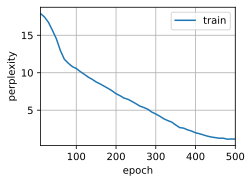

In [11]:
vocab_size, num_hiddens, device = len(vocab), 256, d2l.try_gpu()
num_epochs, lr = 500, 1
model = d2l.RNNModelScratch(len(vocab), num_hiddens, device, get_lstm_params,
                            init_lstm_state, lstm)
d2l.train_ch8(model, train_iter, vocab, lr, num_epochs, device)

### 9.2.3 简洁实现

time traveller                                                  
time traveller  t t t e t t t e t t t e t t t e t t t e t t t e 
time traveller at ae te te te te te te te te te te te te te te t
time travellere the the the the the the the the the the the the 
time travellere the the the the the the the the the the the the 
time traveller the the the the the the the the the the the the t
time travellerererererererererererererererererererererererererer
time traveller an the the the the the the the the the the the th
time travellerereation and and and and and and and and and and a
time traveller the the the the the the the the the the the the t
time traveller the the the the the the the the the the the the t
time traveller the the the the the the the the the the the the t
time traveller the the the the the the the the the the the the t
time traveller the the thered the the there and the the thered t
time traveller and the the there and the the there and the the t
time traveller the the th

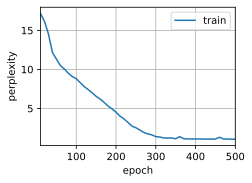

In [13]:
num_inputs = vocab_size
lstm_layer = nn.LSTM(num_inputs, num_hiddens)
model = d2l.RNNModel(lstm_layer, len(vocab))
model = model.to(device)
d2l.train_ch8(model, train_iter, vocab, lr, num_epochs, device)